In [1]:
import h5py
import numpy as np
import gvar as gv
import math
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

# ---------------------------------------------------------
# 2. Data Loading & Filtering Helper
# ---------------------------------------------------------
def load_and_filter_data(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def load_and_filter_data_rm_0_bL(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit) & (bL != 0)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom


def fcn(x, p):
    # 1. Unpack the kinematic arrays from the dictionary x
    kin_re = x['Re']
    kin_im = x['Im']
    
    eta_re, bL_re, bT_re = kin_re[:, 0], kin_re[:, 1], kin_re[:, 2]
    eta_im, bL_im, bT_im = kin_im[:, 0], kin_im[:, 1], kin_im[:, 2]

    # Shared parameter
    f = p['f']
    
    # Real-specific parameters
    val_re = ReA2B(eta_re, bL_re, bT_re, p['a_re'], p['c_re'], p['d_re'], f, p['k1_re'], p['k2_re'], p['j_re'])
    
    # Imaginary-specific parameters
    val_im = ImA2B(eta_im, bL_im, bT_im, p['a_im'], p['c_im'], p['d_im'], f, p['j_im'])
    
    return {'Re': val_re, 'Im': val_im}
    
# ---------------------------------------------------------
# 3. Main Simultaneous Fitting Function
# ---------------------------------------------------------
def FitSimultaneousA2B(PL, bminForFit, etamin, etamax):
    print(f"Simultaneous Fit (ReA2B & ImA2B) : PL={PL}, b_min>={bminForFit}, eta in [{etamin}, {etamax}] ---")
    print("\n--- Fit Functions ---")
    print(inspect.getsource(ReA2B))
    print(inspect.getsource(ImA2B))
    print("---------------------\n")
    
    # 1. Construct file paths (Update the base path if needed)
    base_path = "/pscratch/sd/h/hari_8/TMD_fit/h5data/"
    file_re = f"{base_path}/ReA2B_PL{PL}_jackknife_data.h5"
    file_im = f"{base_path}/ImA2B_PL{PL}_jackknife_data.h5"
    
    # 2. Load and Filter Data
    kin_re, jk_re = load_and_filter_data(file_re, bminForFit, etamin, etamax)
    kin_im, jk_im = load_and_filter_data_rm_0_bL(file_im, bminForFit, etamin, etamax)
    
    N_re = jk_re.shape[0]
    N_im = jk_im.shape[0]
    N_samples = jk_re.shape[1]
    
    print(f"Re A2B points: {N_re}, Im A2B points: {N_im}")

    # 3. Calculate the Full Jackknife Covariance Matrix
    combined_jk = np.vstack([jk_re, jk_im])
    mean_data = np.mean(combined_jk, axis=1)
    diff = combined_jk - mean_data[:, None]
    cov_matrix = ((N_samples - 1) / N_samples) * (diff @ diff.T)
    print(f"Covariance Matrix size: {cov_matrix.shape}")


    """
    k1_re = -4.2916(3905)
k2_re = -4.1908(1714)
    f = 0.5020(0156)
 a_re = 2.1788(2413)
 c_re = 0.4032(1734)
 d_re = 0.0697(0115)
 j_re = 2.4938(1916)
 a_im = 0.2609(0182)
 c_im = 0.4951(0165)
 d_im = 0.1969(0136)
 j_im = 0.8993(0344)
    """
    # ---------------------------------------------------------
    # Set up Priors
    current_prior = {
        # Shared Parameters (Anchored by Real Part)
        'f'    : gv.gvar(0.5, 0.05),   
        'k1_re': gv.gvar(12.27, 0.05),
        'k2_re': gv.gvar(-36.2,0.05),
        'a_re' : gv.gvar(4.01, 0.05),
        'c_re' : gv.gvar(0.146, 0.05),
        'd_re' : gv.gvar(0.094, 0.05),  # Shared: forces consistent broadening
        'j_re' : gv.gvar(2.06,0.05),   # Shared: forces consistent large-b decay
    # Imaginary-specific (Tighter priors to prevent wandering)
        #'k1_im': gv.gvar(-5.5, 2.0),   # MUCH tighter than 50.0
        'a_im' : gv.gvar(0.26,  0.05),  # Magnitude of the T-odd signal
        'c_im' : gv.gvar(0.3,  0.05),
        'd_im' : gv.gvar(0.2, 0.05), 
        'j_im' : gv.gvar(1,0.05),   # Shared: forces consistent large-b decay
    }


    x_dict = {'Re': kin_re, 'Im': kin_im}
    param_names = ['k1_re','k2_re','f','a_re','c_re','d_re','j_re','a_im','c_im','d_im','j_im']
    fitted_params = {key: [] for key in param_names}
    
    # We will also track chi-square per degree of freedom
    chi2_dof_list = []

    for i in tqdm(range(N_samples)):
        y_sample_i = combined_jk[:, i]
        y_gvar_i = gv.gvar(y_sample_i, cov_matrix)
        
        y_dict = {
            'Re': y_gvar_i[:N_re],
            'Im': y_gvar_i[N_re:]
        }
        
        fit = lsqfit.nonlinear_fit(data=(x_dict, y_dict), prior=current_prior, fcn=fcn, debug=False)
        
        for key in fitted_params:
            fitted_params[key].append(fit.pmean[key])
            
        #chi2_dof_list.append(fit.chi2 / (fit.dof - len(param_names)))
        dof = (N_re + N_im) - len(param_names)
        chi2_dof_list.append(fit.chi2 / dof)

    # 7. Apply Jackknife and Print Results
    print("\n--- Final Extracted Parameters ---")
    for key in fitted_params:
        mean_val, err_val = Jackknife(fitted_params[key])
        print(f"{key:>5} = {fmt_err(mean_val, err_val)}")
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    print(f"\n chi^2/dof : {fmt_err(mean_chi2, err_chi2)}\n")
    
    # Return the dictionary of jackknifed parameter arrays in case you want to plot them later
    return fitted_params


# ---------------------------------------------------------
# Plotting Function
# ---------------------------------------------------------
def plot_fourier_transforms(fitted_params, b2, PL, num_points=200):
    # 1. Setup x-axis (avoid exactly 0 to prevent division by zero in Bessel/powers)
    x_vals = np.linspace(-1, 1, num_points)
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2
    j_im = np.array(fitted_params['j_im'])

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []

    print("Evaluating Fourier transforms and applying Jackknife...")
    
    # 3. Loop over each x value and apply your Jackknife function
    for x in x_vals:
        abs_x = np.abs(x)

        # --- Evaluate Real Part for all ~2900 samples at this x ---
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        
        re_evals_at_x = term1_R * term2_R * bessel_R
        
        # Apply your Jackknife function
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part for all ~2900 samples at this x ---
        cd_I = c_im / d_im
        term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
        term2_I = x * abs_x**(-1.5 + j_im)
        bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
        
        im_evals_at_x = term1_I * term2_I * bessel_I
        
        # Apply your Jackknife function
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        m_full, e_full = Jackknife(re_evals_at_x-im_evals_at_x)
        full_mean.append(m_full)
        full_err.append(e_full)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)

    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    #ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    #ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)


    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{A}}_{{2B}}$')
    #ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"/pscratch/sd/h/hari_8/TMD_fit/jupyter/SimulFitCovMatrix-A2B-FT-{param_keys_str}.pdf"
    
    plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=100)
    plt.show()

    return fig, (ax1, ax2, ax3)

Simultaneous Fit (ReA2B & ImA2B) : PL=-1, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = 12.344(19)
k2_re = -36.1862(37)
    f = 0.4771(44)
 a_re = 3.855(10)
 c_re = 0.266(18)
 d_re = 0.1514(62)
 j_re = 1.670(25)
 a_im = 0.302(14)
 c_im = 0.084(28)
 d_im = 0.2818(65)
 j_im = 1.156(25)

 chi^2/dof : 2.18(14)

Evaluating Fourier transforms and applying Jackknife...


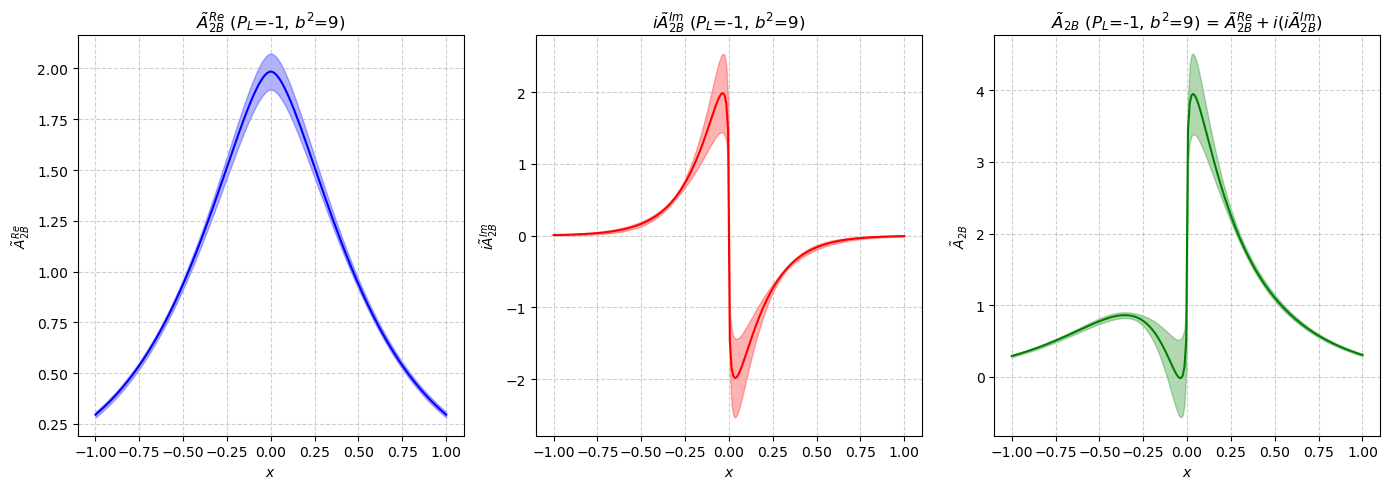

In [2]:
results_4 = FitSimultaneousA2B(PL=-1, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)

Simultaneous Fit (ReA2B & ImA2B) : PL=-2, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = 12.316(17)
k2_re = -36.1899(31)
    f = 0.5307(64)
 a_re = 3.9867(75)
 c_re = 0.174(23)
 d_re = 0.1049(41)
 j_re = 2.055(19)
 a_im = 0.410(13)
 c_im = 0.046(21)
 d_im = 0.1824(88)
 j_im = 1.188(25)

 chi^2/dof : 1.34(11)

Evaluating Fourier transforms and applying Jackknife...


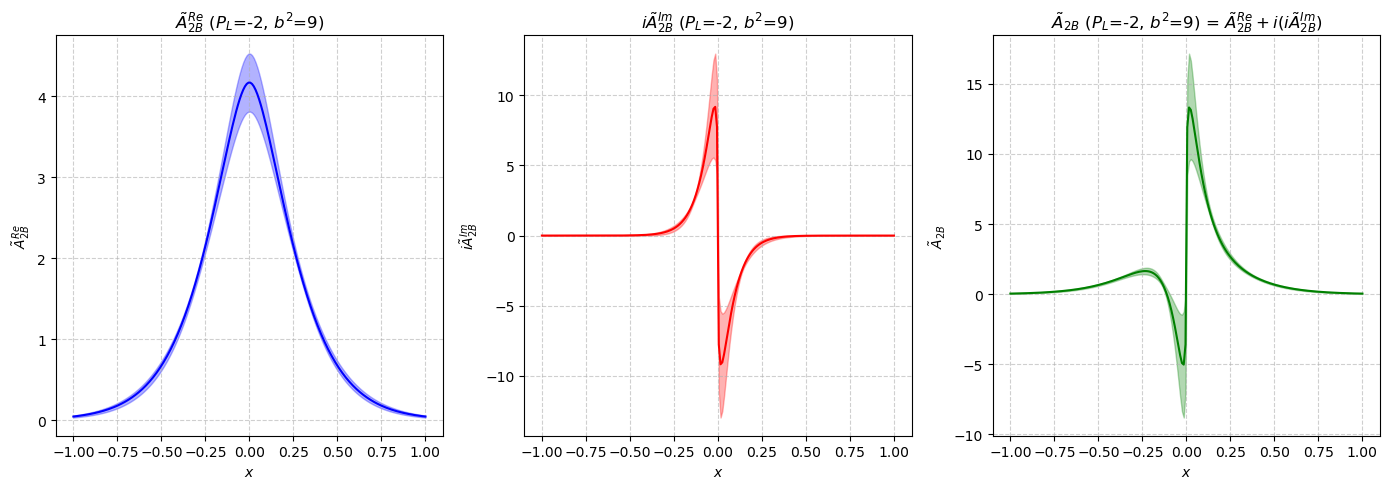

In [3]:
results_4 = FitSimultaneousA2B(PL=-2, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-2)

Simultaneous Fit (ReA2B & ImA2B) : PL=-3, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = 12.297(12)
k2_re = -36.1948(22)
    f = 0.540(13)
 a_re = 3.9994(31)
 c_re = 0.199(18)
 d_re = 0.1303(82)
 j_re = 2.080(11)
 a_im = 0.355(13)
 c_im = 0.220(22)
 d_im = 0.172(17)
 j_im = 1.019(14)

 chi^2/dof : 0.758(86)

Evaluating Fourier transforms and applying Jackknife...


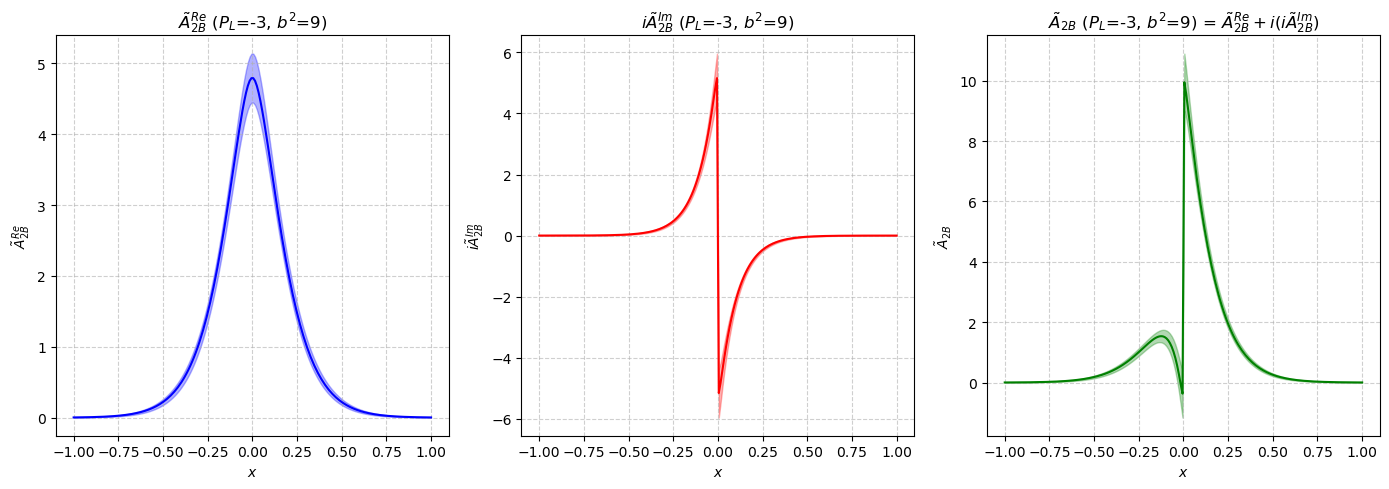

In [2]:
results_4 = FitSimultaneousA2B(PL=-3, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-3)

In [1]:
import h5py
import numpy as np
import gvar as gv
import math
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

# ---------------------------------------------------------
# 2. Data Loading & Filtering Helper
# ---------------------------------------------------------
def load_and_filter_data(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def load_and_filter_data_rm_0_bL(filepath, bminForFit, etamin, etamax):
    """Loads HDF5 data and applies kinematic cuts."""
    with h5py.File(filepath, "r") as f:
        raw_data = f["Dataset1"][:]
        
    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta = kin[:, 0]
    bL  = kin[:, 1]
    bT  = kin[:, 2]
    
    # Calculate b = sqrt(bL^2 + bT^2)
    b_mag = np.sqrt(bL**2 + bT**2)
    
    # Create a boolean mask for our cuts
    mask = (eta >= etamin) & (eta <= etamax) & (b_mag >= bminForFit) & (bL != 0)
    
    # Return only the rows that passed the cuts
    return kin[mask], samples[mask]


def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom


def fcn(x, p):
    # 1. Unpack the kinematic arrays from the dictionary x
    kin_re = x['Re']
    kin_im = x['Im']
    
    eta_re, bL_re, bT_re = kin_re[:, 0], kin_re[:, 1], kin_re[:, 2]
    eta_im, bL_im, bT_im = kin_im[:, 0], kin_im[:, 1], kin_im[:, 2]

    # Shared parameter
    f = p['f']
    
    # --- ENFORCE c > d FOR BOTH REAL AND IMAGINARY PARTS ---
    # Because np.exp() is always strictly > 0, c will always be strictly > d
    c_re_effective = p['d_re'] + np.exp(p['log_delta_c_re'])
    c_im_effective = p['d_im'] + np.exp(p['log_delta_c_im'])
    
    # Real-specific parameters (passing the effective c)
    val_re = ReA2B(eta_re, bL_re, bT_re, p['a_re'], c_re_effective, p['d_re'], f, p['k1_re'], p['k2_re'], p['j_re'])
    
    # Imaginary-specific parameters (passing the effective c)
    val_im = ImA2B(eta_im, bL_im, bT_im, p['a_im'], c_im_effective, p['d_im'], f, p['j_im'])
    
    return {'Re': val_re, 'Im': val_im}
    
# ---------------------------------------------------------
# 3. Main Simultaneous Fitting Function
# ---------------------------------------------------------
def FitSimultaneousA2B(PL, bminForFit, etamin, etamax):
    print(f"Simultaneous Fit (ReA2B & ImA2B) : PL={PL}, b_min>={bminForFit}, eta in [{etamin}, {etamax}] ---")
    print("\n--- Fit Functions ---")
    print(inspect.getsource(ReA2B))
    print(inspect.getsource(ImA2B))
    print("---------------------\n")
    
    # 1. Construct file paths (Update the base path if needed)
    base_path = "/pscratch/sd/h/hari_8/TMD_fit/h5data/"
    file_re = f"{base_path}/ReA2B_PL{PL}_jackknife_data.h5"
    file_im = f"{base_path}/ImA2B_PL{PL}_jackknife_data.h5"
    
    # 2. Load and Filter Data
    kin_re, jk_re = load_and_filter_data(file_re, bminForFit, etamin, etamax)
    kin_im, jk_im = load_and_filter_data_rm_0_bL(file_im, bminForFit, etamin, etamax)
    
    N_re = jk_re.shape[0]
    N_im = jk_im.shape[0]
    N_samples = jk_re.shape[1]
    
    print(f"Re A2B points: {N_re}, Im A2B points: {N_im}")

    # 3. Calculate the Full Jackknife Covariance Matrix
    combined_jk = np.vstack([jk_re, jk_im])
    mean_data = np.mean(combined_jk, axis=1)
    diff = combined_jk - mean_data[:, None]
    cov_matrix = ((N_samples - 1) / N_samples) * (diff @ diff.T)
    print(f"Covariance Matrix size: {cov_matrix.shape}")

    # ---------------------------------------------------------
    # Set up Priors
    # The initial guesses for log_delta are calculated as ln(c_prior - d_prior)
    # Re: ln(0.146 - 0.094) = ln(0.052) ~ -2.95
    # Im: ln(0.3 - 0.2) = ln(0.1) ~ -2.30
    current_prior = {
        # Shared Parameters 
        'f'    : gv.gvar(0.5, 0.05),   
        
        # Real-specific parameters
        'k1_re': gv.gvar(12.27, 0.05),
        'k2_re': gv.gvar(-36.2, 0.05),
        'a_re' : gv.gvar(4.01, 0.05),
        'd_re' : gv.gvar(0.094, 0.05), 
        'log_delta_c_re': gv.gvar(-2.95, 2.0), # Replaces c_re to enforce c_re > d_re
        'j_re' : gv.gvar(2.06, 0.05),  
        
        # Imaginary-specific parameters
        'a_im' : gv.gvar(0.26, 0.05),  
        'd_im' : gv.gvar(0.2, 0.05), 
        'log_delta_c_im': gv.gvar(-2.30, 2.0), # Replaces c_im to enforce c_im > d_im
        'j_im' : gv.gvar(1, 0.05),   
    }

    x_dict = {'Re': kin_re, 'Im': kin_im}
    
    # The parameters we are explicitly handing to the lsqfit optimizer
    fit_param_names = [
        'k1_re','k2_re','f','a_re','log_delta_c_re','d_re','j_re',
        'a_im','log_delta_c_im','d_im','j_im'
    ]
    
    # The physical parameters we actually care to track and print
    track_param_names = [
        'k1_re','k2_re','f','a_re','c_re','d_re','j_re',
        'a_im','c_im','d_im','j_im'
    ]
    fitted_params = {key: [] for key in track_param_names}
    
    # We will also track chi-square per degree of freedom
    chi2_dof_list = []

    for i in tqdm(range(N_samples)):
        y_sample_i = combined_jk[:, i]
        y_gvar_i = gv.gvar(y_sample_i, cov_matrix)
        
        y_dict = {
            'Re': y_gvar_i[:N_re],
            'Im': y_gvar_i[N_re:]
        }
        
        fit = lsqfit.nonlinear_fit(data=(x_dict, y_dict), prior=current_prior, fcn=fcn, debug=False)
        
        # 1. Store the directly fitted standard parameters
        for key in ['k1_re','k2_re','f','a_re','d_re','j_re','a_im','d_im','j_im']:
            fitted_params[key].append(fit.pmean[key])
            
        # 2. Reconstruct and store the physical 'c' parameters to keep Jackknife logic intact
        actual_c_re = fit.pmean['d_re'] + np.exp(fit.pmean['log_delta_c_re'])
        actual_c_im = fit.pmean['d_im'] + np.exp(fit.pmean['log_delta_c_im'])
        
        fitted_params['c_re'].append(actual_c_re)
        fitted_params['c_im'].append(actual_c_im)
            
        dof = (N_re + N_im) - len(fit_param_names)
        chi2_dof_list.append(fit.chi2 / dof)

    # 7. Apply Jackknife and Print Results
    print("\n--- Final Extracted Parameters ---")
    for key in track_param_names:
        mean_val, err_val = Jackknife(fitted_params[key])
        print(f"{key:>5} = {fmt_err(mean_val, err_val)}")
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    print(f"\n chi^2/dof : {fmt_err(mean_chi2, err_chi2)}\n")
    
    # Return the dictionary of jackknifed parameter arrays in case you want to plot them later
    return fitted_params
# ---------------------------------------------------------
# Plotting Function
# ---------------------------------------------------------
def plot_fourier_transforms(fitted_params, b2, PL, num_points=200):
    # 1. Setup x-axis (avoid exactly 0 to prevent division by zero in Bessel/powers)
    x_vals = np.linspace(-1, 1, num_points)
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2
    j_im = np.array(fitted_params['j_im'])

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []

    print("Evaluating Fourier transforms and applying Jackknife...")
    
    # 3. Loop over each x value and apply your Jackknife function
    for x in x_vals:
        abs_x = np.abs(x)

        # --- Evaluate Real Part for all ~2900 samples at this x ---
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        
        re_evals_at_x = term1_R * term2_R * bessel_R
        
        # Apply your Jackknife function
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part for all ~2900 samples at this x ---
        cd_I = c_im / d_im
        term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
        term2_I = x * abs_x**(-1.5 + j_im)
        bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
        
        im_evals_at_x = term1_I * term2_I * bessel_I
        
        # Apply your Jackknife function
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        m_full, e_full = Jackknife(re_evals_at_x-im_evals_at_x)
        full_mean.append(m_full)
        full_err.append(e_full)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)

    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    #ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    #ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)


    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{A}}_{{2B}}$')
    #ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"/pscratch/sd/h/hari_8/TMD_fit/jupyter/SimulFitCovMatrix-A2B-FT-{param_keys_str}.pdf"
    
    plt.savefig(file_name, format='pdf', bbox_inches='tight', dpi=100)
    plt.show()

    return fig, (ax1, ax2, ax3)

Simultaneous Fit (ReA2B & ImA2B) : PL=-1, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = 12.302(22)
k2_re = -36.1935(43)
    f = 0.4738(51)
 a_re = 3.867(11)
 c_re = 0.334(39)
 d_re = 0.1584(78)
 j_re = 1.648(26)
 a_im = 0.265(14)
 c_im = 0.2279(69)
 d_im = 0.2225(66)
 j_im = 1.094(21)

 chi^2/dof : 2.22(14)

Evaluating Fourier transforms and applying Jackknife...


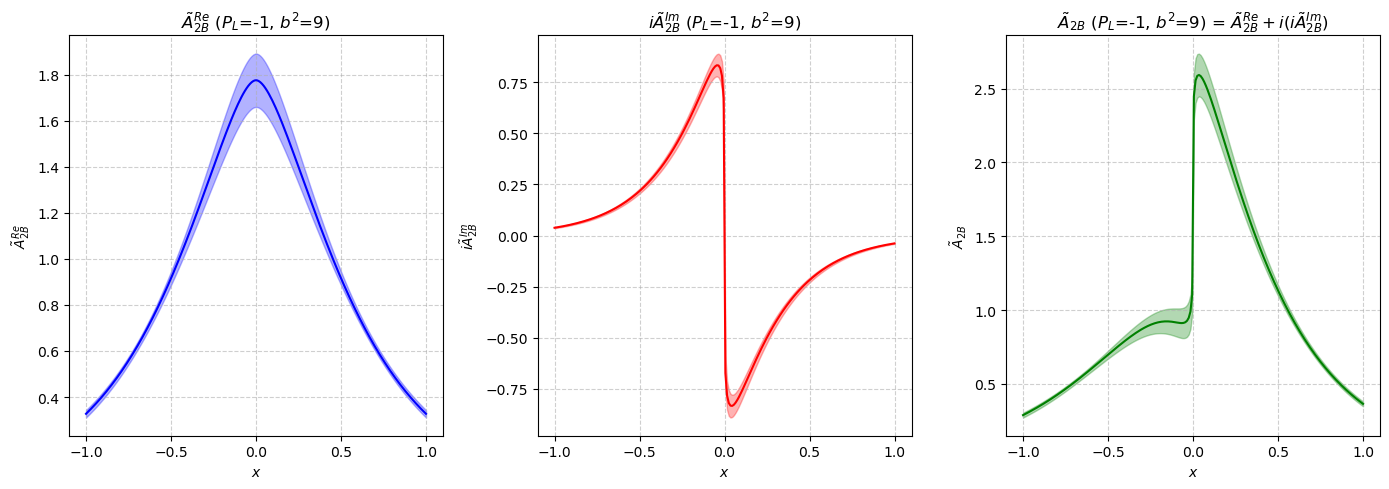

In [2]:
results_4 = FitSimultaneousA2B(PL=-1, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-1)

Simultaneous Fit (ReA2B & ImA2B) : PL=-2, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = 12.310(14)
k2_re = -36.1911(27)
    f = 0.5319(72)
 a_re = 3.9890(74)
 c_re = 0.181(38)
 d_re = 0.1044(49)
 j_re = 2.059(19)
 a_im = 0.371(13)
 c_im = 0.1344(70)
 d_im = 0.1301(68)
 j_im = 1.144(20)

 chi^2/dof : 1.36(12)

Evaluating Fourier transforms and applying Jackknife...


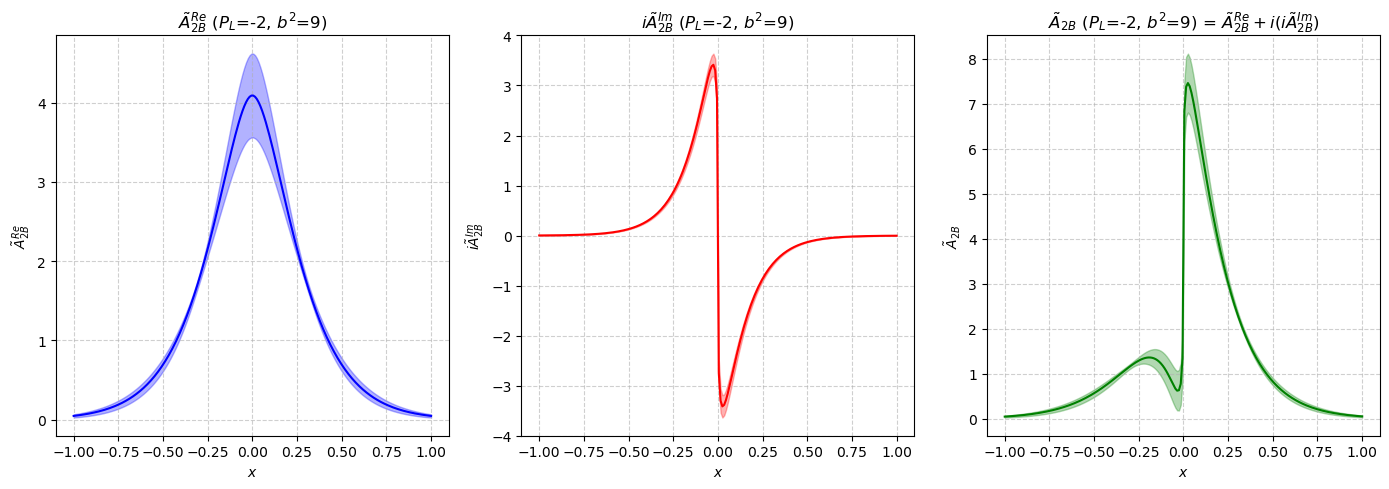

In [3]:
results_4 = FitSimultaneousA2B(PL=-2, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-2)

Simultaneous Fit (ReA2B & ImA2B) : PL=-3, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = 12.280(11)
k2_re = -36.1981(19)
    f = 0.524(16)
 a_re = 4.0039(28)
 c_re = 0.47(14)
 d_re = 0.145(12)
 j_re = 2.079(10)
 a_im = 0.322(12)
 c_im = 0.173(16)
 d_im = 0.156(14)
 j_im = 1.058(15)

 chi^2/dof : 0.732(85)

Evaluating Fourier transforms and applying Jackknife...


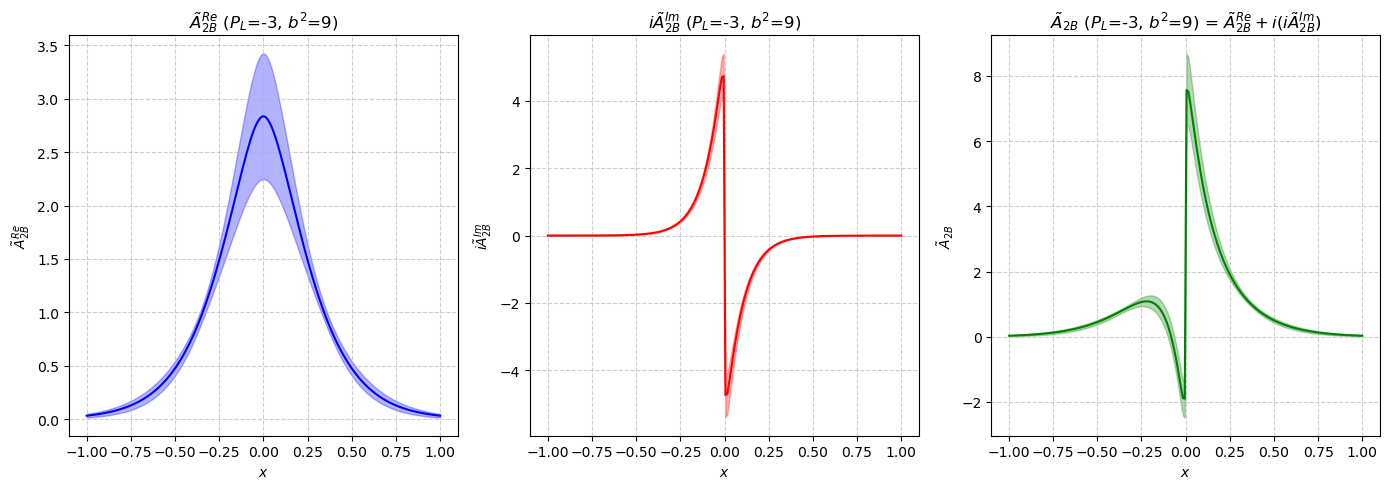

In [4]:
results_4 = FitSimultaneousA2B(PL=-3, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-3)

Simultaneous Fit (ReA2B & ImA2B) : PL=-4, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

---------------------

Re A2B points: 225, Im A2B points: 175
Covariance Matrix size: (400, 400)


  0%|          | 0/2903 [00:00<?, ?it/s]


--- Final Extracted Parameters ---
k1_re = 12.2731(47)
k2_re = -36.19962(70)
    f = 0.552(20)
 a_re = 4.0080(14)
 c_re = 0.29(22)
 d_re = 0.134(14)
 j_re = 2.0674(58)
 a_im = 0.270(13)
 c_im = 0.270(54)
 d_im = 0.195(14)
 j_im = 1.0102(76)

 chi^2/dof : 0.468(69)

Evaluating Fourier transforms and applying Jackknife...


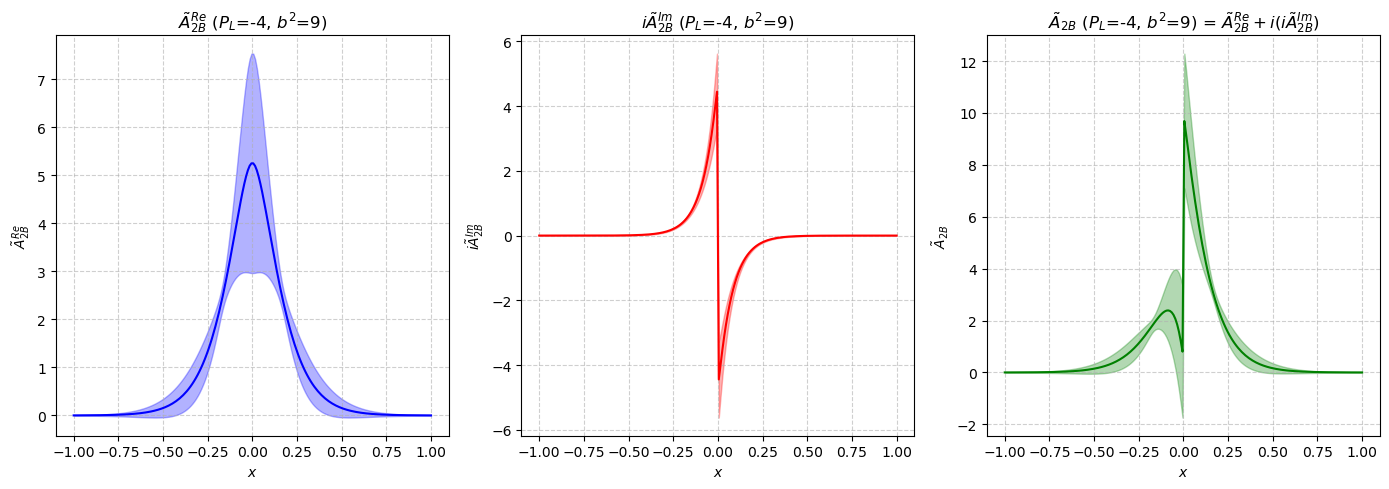

In [5]:
results_4 = FitSimultaneousA2B(PL=-4, bminForFit=3, etamin=6, etamax=10)
fig4, axes4 = plot_fourier_transforms(results_4, b2=9, PL=-4)